# 活性化関数が必要になる理由（2層ニューラルネットワーク）

「活性化関数」は単に出力を0/1に切り替えるための部品ではなく、**層を重ねたときにモデルへ非線形性を導入するため**に必要になります。ここでは「2層ニューラルネットワーク（重み付き和が2回＝隠れ層1つ＋出力層）」を例に、後段の活性化関数がなぜ必要かを先に整理します。

## 2層ニューラルネットワークの計算
入力を $\boldsymbol{x}\in\mathbb{R}^D$、隠れ層ユニット数を $H$、出力を $K$ 次元とすると、典型的には次のように計算します：

$$
\begin{aligned}
\boldsymbol{a}^{(1)} &= W^{(1)}\boldsymbol{x}+\boldsymbol{b}^{(1)} \\
\boldsymbol{z}^{(1)} &= g\!\left(\boldsymbol{a}^{(1)}\right) \\
\boldsymbol{a}^{(2)} &= W^{(2)}\boldsymbol{z}^{(1)}+\boldsymbol{b}^{(2)} \\
\boldsymbol{y} &= f\!\left(\boldsymbol{a}^{(2)}\right)
\end{aligned}
$$

- $g(\cdot)$ が**隠れ層の活性化関数**（ステップ／シグモイド／ReLU など）
- $f(\cdot)$ が**出力層の活性化関数**（分類ならソフトマックス、2値分類ならシグモイド、回帰なら恒等関数など）

## 活性化関数がないと「層を重ねても1層と同じ」になる
もし隠れ層で活性化を入れず $\boldsymbol{z}^{(1)}=\boldsymbol{a}^{(1)}$ とすると、
$$
\boldsymbol{a}^{(2)}=W^{(2)}\left(W^{(1)}\boldsymbol{x}+\boldsymbol{b}^{(1)}\right)+\boldsymbol{b}^{(2)}
=\underbrace{\left(W^{(2)}W^{(1)}\right)}_{\text{1つの行列}}\boldsymbol{x}+\underbrace{\left(W^{(2)}\boldsymbol{b}^{(1)}+\boldsymbol{b}^{(2)}\right)}_{\text{1つのバイアス}}
$$
となり、結局「入力に対する**1回の線形変換（アフィン変換）**」にまとめられます。つまり、活性化関数がない限り、層を増やしても表現力は本質的に増えません。

## 出力層にも活性化関数が要る理由
最後の $f(\cdot)$ は、タスクに合わせて出力の意味を決めます。たとえば多クラス分類では、ソフトマックスにより $\boldsymbol{y}$ を「各クラスの確率（合計1）」として解釈でき、損失関数（交差エントロピー）とも整合します。2値分類ならシグモイド、回帰なら恒等関数がよく使われます。

以降では、これら $g(\cdot)$ や $f(\cdot)$ の代表例としてステップ関数・シグモイド・ReLU・ソフトマックスを順に見ていきます。

# ch03/step_function.py

## ステップ関数（step function）の数学的な解説

**定義（Heaviside関数 / 指示関数）**
$$
f(x)=\begin{cases}
1 & (x>0)\\
0 & (x\le 0)
\end{cases}
$$

- 出力は $\{0,1\}$ の2値で、しきい値で不連続に切り替わります。一般にしきい値 $\theta$ を入れて $f(x)=\mathbf{1}[x>\theta]$ と書くこともあります。
- 多次元入力 $\boldsymbol{x}$ に対しては、成分ごと（elementwise）に同じ関数を適用します。ノートブックの `np.array(x > 0, dtype=int)` はこの $\mathbf{1}[\cdot]$ をベクトル化して計算しています。

**連続性・微分可能性**
- $x=0$ で不連続なので連続ではありません。
- 導関数は $x\neq 0$ では $0$、$x=0$ では（古典的な意味では）未定義です：
$$
f'(x)=0\ (x\neq 0),\quad f'(0)\ \text{は未定義}
$$
このため、勾配に基づく学習（誤差逆伝播）では、そのままでは扱いにくい活性化関数です。

**歴史的背景（原論文との対応）**
- 「ニューロンの発火は all-or-none（起こる/起こらない）」という理想化は、しきい値型の2値出力モデルに直結します。McCulloch & Pitts はこの前提の下で、ニューロンを論理素子として扱えることを論じています [1]。
- その後のパーセプトロンでも、重み付き和がしきい値を超えると出力が切り替わる（実質的にステップ関数）という形式が中心になります [2]。

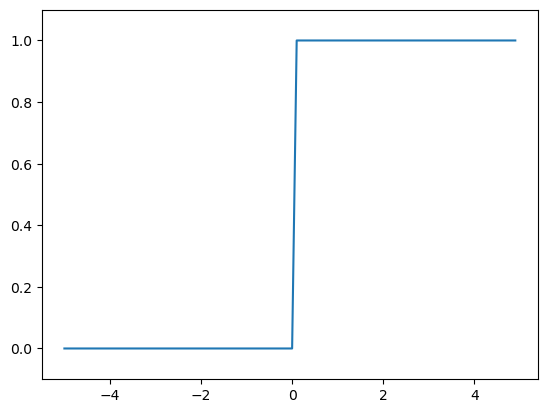

In [8]:
import numpy as np
import matplotlib.pylab as plt


def step_function(x):
    return np.array(x > 0, dtype=int)

X = np.arange(-5.0, 5.0, 0.1)
Y = step_function(X)
plt.plot(X, Y)
plt.ylim(-0.1, 1.1)  # 図で描画するy軸の範囲を指定
plt.show()

# ch03/sigmoid.py

## シグモイド関数（sigmoid）の数学的な解説

**定義（ロジスティック関数）**
$$
\sigma(x)=\frac{1}{1+e^{-x}}
$$

**値域と極限**
- 値域は $\sigma(x)\in(0,1)$（どんな $x$ でも厳密に0/1にはなりません）。
- $x\to -\infty$ で $\sigma(x)\to 0$、$x\to +\infty$ で $\sigma(x)\to 1$。

**導関数（誤差逆伝播で決定的に重要）**
$$
\sigma'(x)=\sigma(x)\,\bigl(1-\sigma(x)\bigr)
$$
- これにより、層をまたいで微分（連鎖律）を適用する計算が可能になります。RHW(1986) は、内部表現を学習するために誤差を逆向きに伝播させる（back-propagation）枠組みを示し、そこで微分可能な非線形が中心的に使われます [6]。

**飽和と勾配消失（シグモイドの典型的な弱点）**
- $\sigma'(x)$ の最大値は $x=0$ のとき $1/4$。
- $|x|$ が大きいと $\sigma(x)$ が0または1に“飽和”して $\sigma'(x)\approx 0$ になり、層を重ねたときに勾配が小さくなりやすい（学習が進みにくくなる）要因になります。

**「ステップ関数の滑らかな近似」としての見方**
傾きを $a>0$ とした
$$
\sigma_a(x)=\frac{1}{1+e^{-ax}}
$$
は $a$ が大きいほど切り替わりが急になり、$a\to\infty$ でステップ関数に近づきます。

**原論文との対応（ロジスティック曲線）**
- ロジスティック曲線は人口増加の研究などで現れ、Verhulst によって論じられています [3]。ニューラルネットでは、しきい値の“硬い”切り替え（ステップ）を、微分可能な“滑らかな”切り替えで置き換える意図で用いられます。

**実装上の注意**
- 多次元入力でも成分ごとに適用します（elementwise）。
- 指数関数を使うので、極端に大きい $|x|$ では数値的に不安定になり得ます（実務では入力のスケーリングや安定化実装を併用します）。

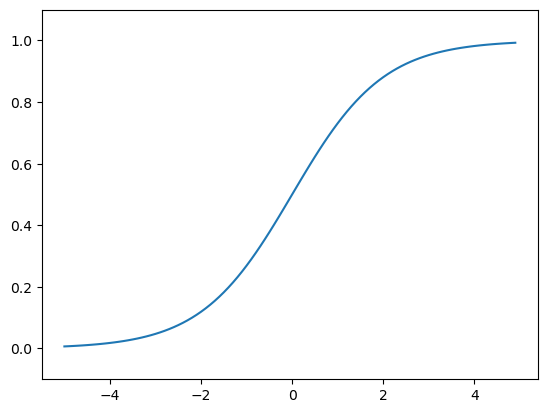

In [9]:
import numpy as np
import matplotlib.pylab as plt


def sigmoid(x):
    return 1 / (1 + np.exp(-x))

X = np.arange(-5.0, 5.0, 0.1)
Y = sigmoid(X)
plt.plot(X, Y)
plt.ylim(-0.1, 1.1)
plt.show()


# ch03/sig_step_compare.py

## ステップ関数とシグモイド関数の比較（数学的観点＋原論文の文脈）

どちらも「入力を $[0,1]$ 付近に写像する」単調増加関数であり、極限は似ています：
$$
\lim_{x\to-\infty}f(x)=0,\quad \lim_{x\to+\infty}f(x)=1
$$

ただし学習（微分・勾配）の観点では決定的な差があります。

**1) 連続性・微分可能性**
- ステップ関数は $x=0$ で不連続で、古典的な意味では微分が定義できません。
- シグモイドは滑らかで、どこでも微分可能です。RHW(1986) の back-propagation は誤差を逆向きに伝播させる際に連鎖律を繰り返し適用するため、こうした微分可能な非線形が実装上・理論上の基盤になります [6]。

**2) 「硬いしきい値」→「滑らかなしきい値」**
- McCulloch & Pitts は発火を all-or-none として理想化し、しきい値型の2値出力（論理素子）として議論します [1]。
- Rosenblatt のパーセプトロンも、重み付き和がしきい値を超えると反応する形式が中心で、これは実質的にステップ関数です [2]。
- これに対してシグモイドは、ロジスティック曲線（Verhulst）[3] を用いて「しきい値の切り替え」を滑らかにしたもの、とみなせます。

**3) 勾配の大きさ（学習のしやすさ）**
- シグモイドは導関数が $\sigma'(x)=\sigma(x)(1-\sigma(x))$ で、最大でも $1/4$、さらに飽和領域では $\approx 0$ になります。
- したがって層を深くすると、逆伝播で掛け合わされる微小な係数が増え、勾配が小さくなりやすい（学習が進みにくい）という直観につながります。

**4) その後の代表例：ReLU**
この「飽和して勾配が小さくなりやすい」問題に対して、後の研究では ReLU のような（少なくとも正の領域で）非飽和な活性化が広く使われるようになります [5]。

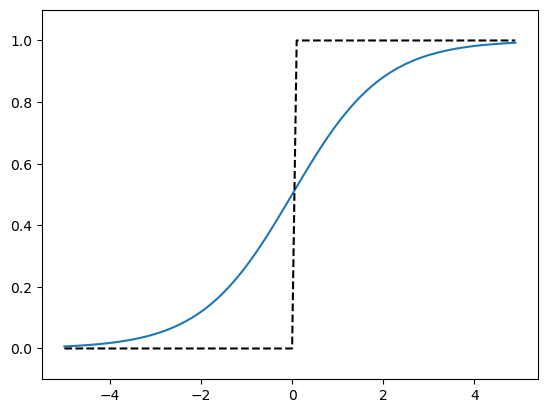

In [10]:
import numpy as np
import matplotlib.pylab as plt


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def step_function(x):
    return np.array(x > 0, dtype=int)

x = np.arange(-5.0, 5.0, 0.1)
y1 = sigmoid(x)
y2 = step_function(x)

plt.plot(x, y1)
plt.plot(x, y2, 'k--')
plt.ylim(-0.1, 1.1) #図で描画するy軸の範囲を指定
plt.show()

# ch03/relu.py

## ReLU（Rectified Linear Unit）の数学的な解説

**定義**
$$
\operatorname{ReLU}(x)=\max(0,x)
$$

**導関数（サブグラディエント）**
$$
\operatorname{ReLU}'(x)=\begin{cases}
0 & (x<0)\\
1 & (x>0)
\end{cases}
$$
- $x=0$ では厳密には微分不可ですが、実装では $0$ などのサブグラディエントを用います。

**性質（学習への影響）**
- $x>0$ では勾配が $1$ のため、シグモイドのように正側で飽和して勾配が小さくなる現象が起きにくいです。
- $x<0$ では出力も勾配も $0$ になり、活性が疎（スパース）になりやすい一方、重み更新が止まって“死んだReLU（dying ReLU）”になることがあります。

**原論文との対応**
- ReLU を用いた学習上の利点（特に勾配が流れやすいこと、スパースな表現になりやすいこと）については、Nair & Hinton が RBM の文脈で整理しています [5]。

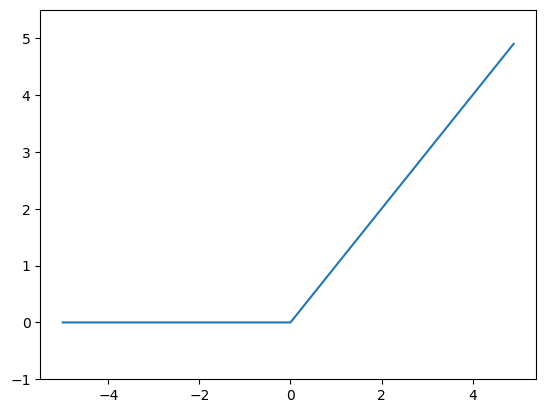

In [11]:
import numpy as np
import matplotlib.pylab as plt


def relu(x):
    return np.maximum(0, x)

x = np.arange(-5.0, 5.0, 0.1)
y = relu(x)
plt.plot(x, y)
plt.ylim(-1.0, 5.5)
plt.show()

# ch03/mnist_show.py

In [12]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
from dataset.mnist import load_mnist
from PIL import Image


def img_show(img):
    pil_img = Image.fromarray(np.uint8(img))
    pil_img.show()

(x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=False)

img = x_train[0]
label = t_train[0]
print(label)  # 5

print(img.shape)  # (784,)
img = img.reshape(28, 28)  # 形状を元の画像サイズに変形
print(img.shape)  # (28, 28)

img_show(img)

5
(784,)
(28, 28)


# ch03/neuralnet_mnist.py

## （補足）ソフトマックス関数（softmax）の数学的な解説

このノートブック後半の推論コードでは、出力層で `softmax` を使っています。softmax は **ベクトル** $\boldsymbol{z}\in\mathbb{R}^K$ を確率分布へ写像する活性化関数です（シグモイド/ ReLU のような要素ごとの関数とは少し違います）。

**定義**
$$
\operatorname{softmax}(\boldsymbol{z})_i=\frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}\quad (i=1,\dots,K)
$$

**性質**
- 各成分は $\in(0,1)$ で、総和は $\sum_i \operatorname{softmax}(\boldsymbol{z})_i=1$（確率として解釈可能）。
- 定数シフトに不変：任意の $c$ について $\operatorname{softmax}(\boldsymbol{z})=\operatorname{softmax}(\boldsymbol{z}-c\mathbf{1})$。この性質を使い、実装では $\max_i z_i$ を引いて指数のオーバーフローを避けます。

**原論文との対応（確率分布への変換）**
- 出力層の「スコア」を確率分布に変換する方法として、Denker & LeCun は正規化された指数関数形（いわゆる softmax を含む）を用いる考え方を整理しています [4]。

In [13]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import pickle
from dataset.mnist import load_mnist
from common.functions import sigmoid, softmax


def get_data():
    (x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=True, one_hot_label=False)
    return x_test, t_test


def init_network():
    with open("../ch03/sample_weight.pkl", 'rb') as f:
        network = pickle.load(f)
    return network


def predict(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = softmax(a3)

    return y


x, t = get_data()
network = init_network()
accuracy_cnt = 0
for i in range(len(x)):
    y = predict(network, x[i])
    p= np.argmax(y) # 最も確率の高い要素のインデックスを取得
    if p == t[i]:
        accuracy_cnt += 1

print("Accuracy:" + str(float(accuracy_cnt) / len(x)))

Accuracy:0.9352


# ch03/neuralnet_mnist_batch.py

In [14]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import pickle
from dataset.mnist import load_mnist
from common.functions import sigmoid, softmax


def get_data():
    (x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=True, one_hot_label=False)
    return x_test, t_test


def init_network():
    with open("../ch03/sample_weight.pkl", 'rb') as f:
        network = pickle.load(f)
    return network


def predict(network, x):
    w1, w2, w3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, w1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, w2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, w3) + b3
    y = softmax(a3)

    return y


x, t = get_data()
network = init_network()

batch_size = 100 # バッチの数
accuracy_cnt = 0

for i in range(0, len(x), batch_size):
    x_batch = x[i:i+batch_size]
    y_batch = predict(network, x_batch)
    p = np.argmax(y_batch, axis=1)
    accuracy_cnt += np.sum(p == t[i:i+batch_size])

print("Accuracy:" + str(float(accuracy_cnt) / len(x)))


Accuracy:0.9352


# References

[1] Warren S. McCulloch and Walter Pitts. *A Logical Calculus of the Ideas Immanent in Nervous Activity*. Bulletin of Mathematical Biophysics, 5:115–133 (1943). （再録版が流通しています）

[2] Frank Rosenblatt. *The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain*. Psychological Review, 65(6) (1958).

[3] P.-F. Verhulst. *Recherches mathématiques sur la loi d'accroissement de la population*. Nouveaux mémoires de l'Académie Royale des Sciences et Belles-Lettres de Bruxelles (1845).

[4] John S. Denker and Yann LeCun. *Transforming Neural-Net Output Levels to Probability Distributions*. NIPS (1990).

[5] Vinod Nair and Geoffrey E. Hinton. *Rectified Linear Units Improve Restricted Boltzmann Machines*. ICML (2010).

[6] David E. Rumelhart, Geoffrey E. Hinton, and Ronald J. Williams. *Learning representations by back-propagating errors*. Nature 323 (1986).